<a href="https://colab.research.google.com/github/valencialunacarolay-dot/POOP4/blob/main/Tema_06_FiltrosDigitales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tema 6: Entendiendo los filtros digitales

In [ ]:
# Cargamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

Funciones que serán útiles

In [ ]:
# Espectro de amplitud
def get_amp_spectrum(data, dt):
    n = len(data)
    f = fftfreq(n, dt)[:n//2]
    amp = np.abs(fft(data)[:n//2]) * 2 / n
    return f, amp

# Espectro de fase
def get_phase_spectrum(data, dt):
    n = len(data)
    f = fftfreq(n, dt)[:n//2]
    fft_val = fft(data)[:n//2]
    phase_sp = np.angle(fft_val)
    return f, phase_sp, phase_sp * 180 / np.pi

# Obtenemos los coeficientes dell filtro
def get_filter_coeff(tipo_filtro,orden,f_corte,fN,tipo_fil='lowpass'):

    f_corte=np.array(f_corte)

    if tipo_filtro == 'cheby1':
        b, a = signal.iirfilter(orden, f_corte/fN, rp=10, btype=tipo_fil, analog=False, ftype='cheby1')
    elif tipo_filtro == 'cheby2':
        b, a = signal.iirfilter(orden, f_corte/fN, rs=40, btype=tipo_fil, analog=False, ftype='cheby2')
    elif tipo_filtro == 'ellip':
        b, a = signal.iirfilter(orden, f_corte/fN, rp=5, rs=40, btype=tipo_fil, analog=False, ftype='ellip')
    else:
        b, a = signal.iirfilter(orden, f_corte/fN, btype=tipo_fil, analog=False, ftype=tipo_filtro)
    return b, a

Lectura de datos

In [ ]:
Datos = np.loadtxt('Tepich_YUC.dat')
t=Datos[:,0]
s=Datos[:,1]

# Tasa de muestreo y frecuencia de Nyquist
dt=Datos[1,0]-Datos[0,0]
fs=1/dt
fN=fs/2
print(dt,fs,fN)

0.025 40.0 20.0


Decidimos qué filtro usar

In [ ]:
# Configuración del filtro
orden = 4
f_corte = [0.5, 15.5] # Hz
tipo_filtro = 'bessel' # Opciones: 'butter', 'cheby1', 'cheby2', 'ellip', 'bessel'
tipo_fil = 'bandstop' # Opciones: 'lowpass', 'highpass', 'bandpass', 'bandstop'
b, a = get_filter_coeff(tipo_filtro,orden,f_corte,fN,tipo_fil=tipo_fil)

Vemos la forma de la función de transferencia del filtro

--- Coeficientes del filtro bessel ---
Numerador (b): [ 0.00890855 -0.05754928  0.1750474  -0.32274942  0.39288122 -0.32274942
  0.1750474  -0.05754928  0.00890855]
Denominador (a): [ 1.         -1.76004609 -0.54753148  1.68747862  0.5631436  -0.85995586
 -0.3339369   0.17192593  0.07911792]


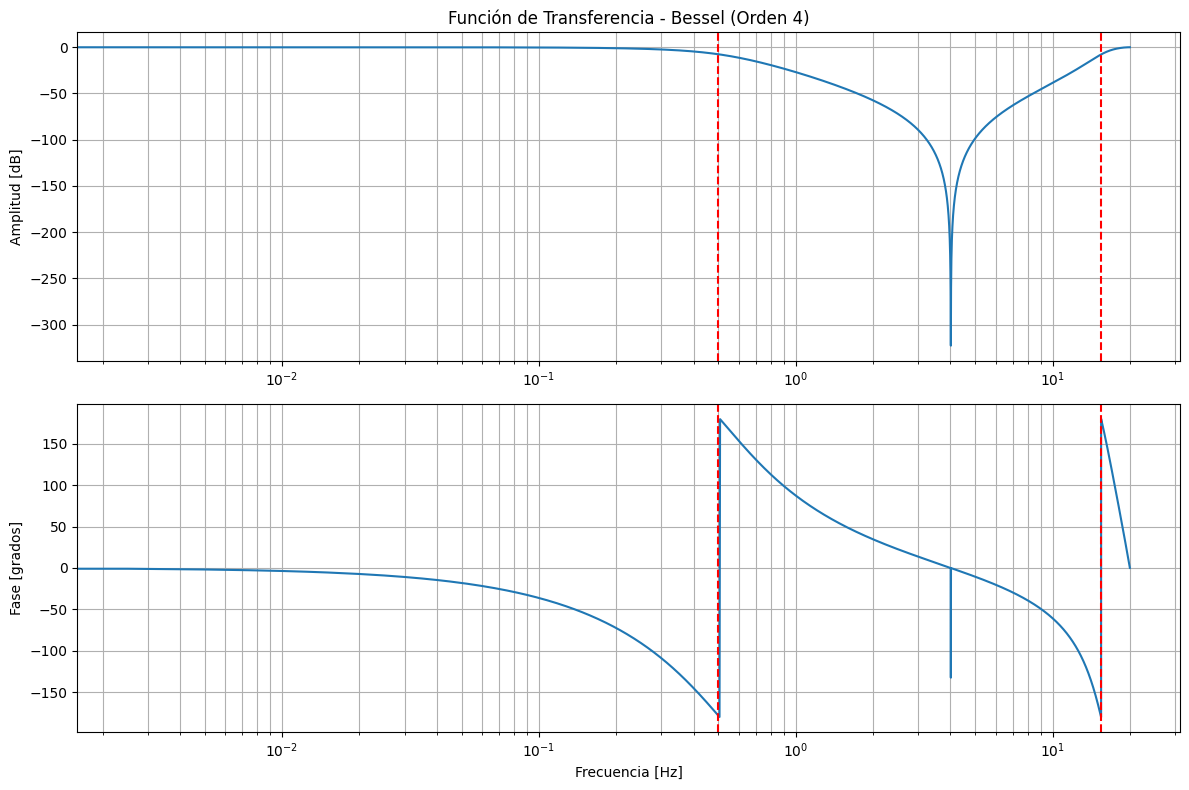

In [ ]:
# Construcción de la Función de Transferencia H(z)
# H(z) = (b0 + b1*z^-1 + ...) / (1 + a1*z^-1 + ...)
print(f"--- Coeficientes del filtro {tipo_filtro} ---")
print(f"Numerador (b): {b}")
print(f"Denominador (a): {a}")

# Respuesta en frecuencia (Amplitud y Fase)
w, h = signal.freqz(b, a, worN=8000)
freq_hz = (w * fN) / np.pi

plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.semilogx(freq_hz, 20 * np.log10(abs(h)))
plt.title(f'Función de Transferencia - {tipo_filtro.capitalize()} (Orden {orden})')
plt.ylabel('Amplitud [dB]')
plt.grid(which='both', axis='both')
for i, fc in enumerate(np.atleast_1d(f_corte)):
    plt.axvline(fc, color='red', linestyle='--',
                label='Corte' if i == 0 else None)

plt.subplot(2, 1, 2)
plt.semilogx(freq_hz, np.angle(h) * 180 / np.pi)
plt.ylabel('Fase [grados]')
plt.xlabel('Frecuencia [Hz]')
plt.grid(which='both', axis='both')
for i, fc in enumerate(np.atleast_1d(f_corte)):
    plt.axvline(fc, color='red', linestyle='--',
                label='Corte' if i == 0 else None)
plt.tight_layout()
plt.show()

Aplicamos el filtro a nuestra señal (una pasada; causal)

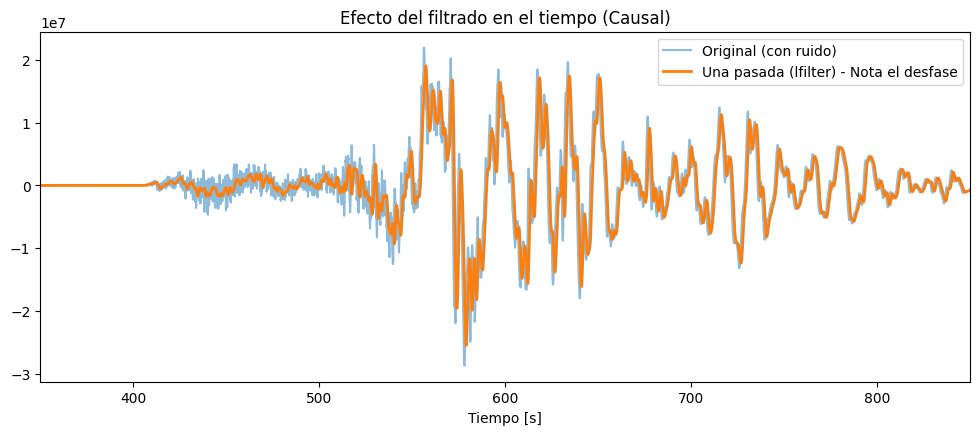

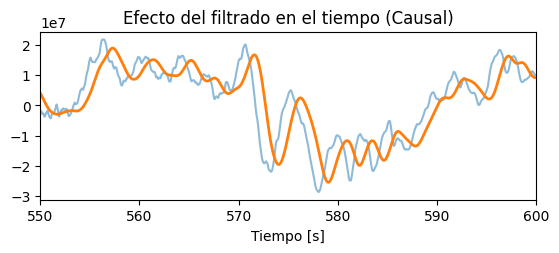

In [ ]:
# Aplicación: Una pasada (Causal)
s_una_pasada = signal.lfilter(b, a, s)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(t, s, label='Original (con ruido)', alpha=0.5)
plt.plot(t, s_una_pasada, label='Una pasada (lfilter) - Nota el desfase', linewidth=2)
plt.title('Efecto del filtrado en el tiempo (Causal)')
plt.legend()
plt.xlabel('Tiempo [s]')
plt.xlim(350, 850) # Zoom para ver el desfase
plt.show()

plt.subplot(2, 1, 2)
plt.plot(t, s, label='Original (con ruido)', alpha=0.5)
plt.plot(t, s_una_pasada, label='Una pasada (lfilter) - Nota el desfase', linewidth=2)
plt.title('Efecto del filtrado en el tiempo (Causal)')
#plt.legend()
plt.xlabel('Tiempo [s]')
plt.xlim(550, 600) # Zoom para ver el desfase
plt.show()

Aplicamos el filtro a nuestra señal (dos pasadas; fase cero)

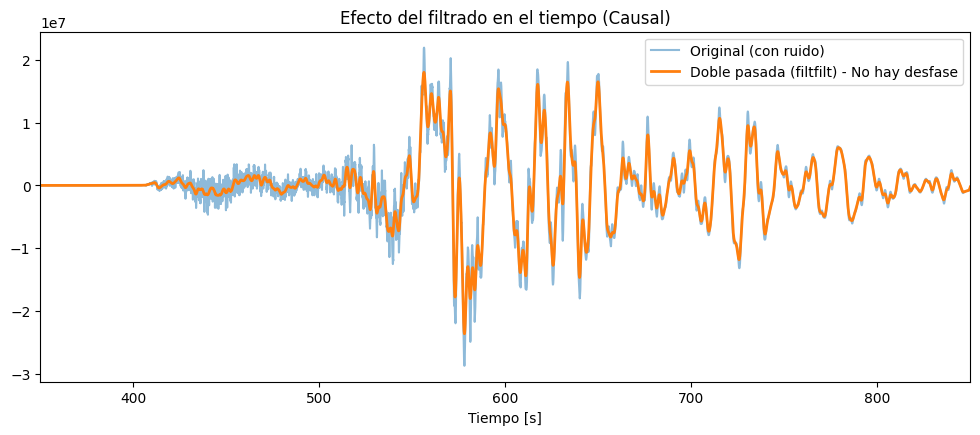

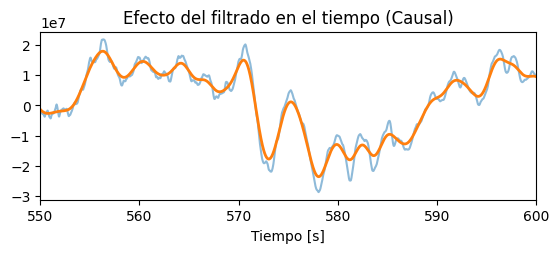

In [ ]:
# Doble pasada (Zero-phase) y comparación de fase
s_doble_pasada = signal.filtfilt(b, a, s)

plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
plt.plot(t, s, label='Original (con ruido)', alpha=0.5)
plt.plot(t, s_doble_pasada, label='Doble pasada (filtfilt) - No hay desfase', linewidth=2)
plt.title('Efecto del filtrado en el tiempo (Causal)')
plt.legend()
plt.xlabel('Tiempo [s]')
plt.xlim(350, 850) # Zoom para ver el desfase
plt.show()

plt.subplot(2, 1, 2)
plt.plot(t, s, label='Original (con ruido)', alpha=0.5)
plt.plot(t, s_doble_pasada, label='Una pasada (lfilter) - Nota el desfase', linewidth=2)
plt.title('Efecto del filtrado en el tiempo (Causal)')
#plt.legend()
plt.xlabel('Tiempo [s]')
plt.xlim(550, 600) # Zoom para ver el desfase
plt.show()

Espectros de fase (una pasada vs doble pasada)

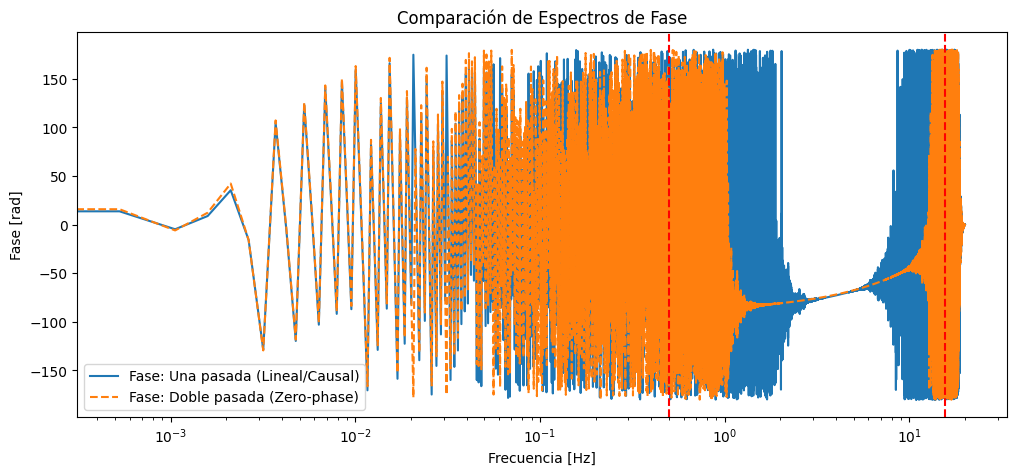

In [ ]:
# Espectros de fase

f_p, _, phase_1_deg = get_phase_spectrum(s_una_pasada, dt)
_, _, phase_2_deg = get_phase_spectrum(s_doble_pasada, dt)

plt.figure(figsize=(12, 5))
plt.semilogx(f_p, phase_1_deg, label='Fase: Una pasada (Lineal/Causal)')
plt.semilogx(f_p, phase_2_deg, label='Fase: Doble pasada (Zero-phase)', linestyle='--')
plt.title('Comparación de Espectros de Fase')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [rad]')
plt.legend()
for i, fc in enumerate(np.atleast_1d(f_corte)):
    plt.axvline(fc, color='red', linestyle='--',
                label='Corte' if i == 0 else None)
#plt.xlim(0, f_corte * 2)
plt.show()

Comparación del espectro de amplitudes de la señal original y la filtrada

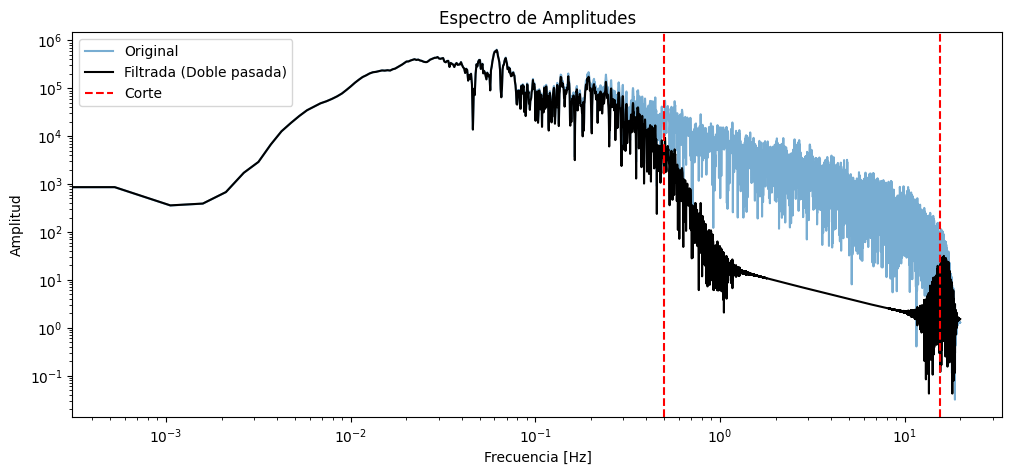

In [ ]:
# Espectro de amplitud

f_a, amp_orig = get_amp_spectrum(s, dt)
_, amp_filt = get_amp_spectrum(s_doble_pasada, dt)

plt.figure(figsize=(12, 5))
plt.semilogx(f_a, amp_orig, label='Original', alpha=0.6)
plt.semilogx(f_a, amp_filt, label='Filtrada (Doble pasada)', color='black')
for i, fc in enumerate(np.atleast_1d(f_corte)):
    plt.axvline(fc, color='red', linestyle='--',
                label='Corte' if i == 0 else None)
plt.title('Espectro de Amplitudes')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud')
plt.yscale('log')
plt.legend()
plt.show()